## Feature Engineering By Krish Naik


In [1]:
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

In [3]:
type(df)

pandas.core.frame.DataFrame

In [7]:
df.head()    # .head() shows first 5 rows

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.isnull() 
# check missisng value
# It returns a DataFrame of True/False values
# Each cell = True if the value is NaN, else False.

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum() # it checks sum of missing value in each column 

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
df.shape 
#shows there are 891 data points in dataset
# 891 rows and 15 columns

(891, 15)

In [11]:
df.dropna().shape 

#dropping all null values
# it converts data from 891 rows to 182 rows so this is bad idea because we lost so many data

(182, 15)

In [12]:
df.dropna(axis=1)
# Drop (remove) all rows or columns that contain missing values (NaN).

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


### Imputation techniques missing values



In [ ]:
"""
What is Imputation?

Imputation means filling in the missing values (NaN) in your dataset with some meaningful values instead of deleting the rows or columns.

💡 Why we use it:

Because missing data can cause problems while analyzing or training machine learning models.

If you just delete all rows/columns with NaN (dropna()), you may lose important information.

So instead, we replace (or “impute”) those missing values with reasonable guesses.

"""

### 1 - Mean value imputation

In [9]:
df['age'].mean()

np.float64(29.69911764705882)

In [6]:
df['mean_age'] = df['age'].fillna(df['age'].mean())

In [8]:
df[['mean_age','age']]

,mean_age,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


### 2. Median Value imputation - If we have outliers in the dataset

In [15]:
df['age'].median

<bound method Series.median of 0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64>

In [13]:
df['age_median'] = df['age'].fillna(df['age'].median)

In [16]:
df[['age_median','mean_age','age']]

,age_median,mean_age,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,<bound method Series.median of 0 22.0\n1 ...,29.699118,NaN
889,26.0,26.000000,26.0


### 3. Mode Imputation Techniques - Categorical Values

In [23]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [17]:
mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]
# filters the DataFrame to include only rows where embarked is not NaN.
# df['embarked']
# → selects the embarked column.
# ['embarked']
# → selects that cleaned column.

# .mode()
# → finds the most frequent (mode) value from that column.

# [0]
# → extracts the actual value (since .mode() returns a Series).


In [18]:
df['embarked_mode'] = df['embarked'].fillna(mode_value)

In [29]:
df[['embarked_mode','embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [30]:
df['embarked_mode'].isnull().sum()

0

In [31]:
df['embarked'].isnull().sum()

2

## Handeling Imbalanced Data

##### 1. Up sampling
##### 2. Down sampling

In [34]:
import numpy as np
import pandas as pd

# numpy for numerical operations
# pandas for creating and managing tabular data (DataFrame)

# Set the random seed for reproducibility
np.random.seed(123)
#This sets the random seed — it ensures that whenever you generate random numbers, you’ll always get the same result.
#(Useful for reproducibility — especially in experiments or ML work.)

#  Create data frame with 2 classes
n_sample = 1000
# ✅ Total number of samples (rows) in the dataset = 1000
class_0_ratio = 0.9
#✅ I am saying 90% of samples belong to class 0,
# and the rest 10% belong to class 1.
# So, we’ll have 900 class 0 samples and 100 class 1 samples.
n_class_0 = int(n_sample * class_0_ratio)
n_class_1 = n_sample - n_class_0

# ✅ Here you’re calculating:
# n_class_0 = 900
# n_class_1 = 100

In [35]:
n_class_0, n_class_1

(900, 100)

In [ ]:
"""
🔍 What is an “imbalanced dataset”?

👉 When you have unequal numbers of examples in each class of your target variable —
that dataset is called an imbalanced dataset.

Here, class 0 is the majority class,
and class 1 is the minority class.

🧠 Why we create (or study) imbalanced datasets?

Because in real life, most classification problems are imbalanced 
— and we must learn how to handle them.

🔚 Summary

So Omkar, we create imbalanced datasets because:

✅ They represent real-world problems
✅ We can practice how to balance and handle them
✅ We learn that accuracy alone doesn’t tell the truth

"""

In [36]:
## create dataset with imbalanced dataset
class_0 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'target' : [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2' : np.random.normal(loc=0, scale=1, size=n_class_1),
    'target' : [1] * n_class_1
})

"""
1) "loc" means The mean (center) of the distribution.
So here is The mean is 0 → most values are near 0.

2) "scale" : The standard deviation (spread) of the distribution.
The spread (standard deviation) is 1 → most values lie between -1 and +1

Example: 
np.random.normal(loc=10, scale=2, size=5)
output: array([8.9, 12.2, 11.5, 7.6, 9.8])
Explanation:
The mean is 10 → most values are near 10
The spread (standard deviation) is 2 → most values lie between 8 and 12

### Why not only one feature?

If you use only one feature, your model or analysis can only learn from one kind of information.
But in real-world data, outcomes depend on many factors together.

💡 Example:

To predict if a person will buy a car, we need income, age, city, etc.
Not just one of them.

So, we use multiple features (feature_1, feature_2, … feature_n) to make the data more realistic and useful for modeling.

"""


In [37]:
df = pd.concat ([class_0,class_1]).reset_index(drop=True)

"""
.reset_index(drop=True) means:

# When we join two DataFrames (like class_0 and class_1),
# their old row numbers (indexes) also get joined.
# class_0 → indexes 0 to 899
# class_1 → indexes 0 to 99
# So the index numbers repeat.

✅ To fix that:

We use .reset_index(drop=True) — it simply:

Removes old index numbers
Creates new continuous indexes → 0, 1, 2, 3, …

drop=True just means don’t keep the old index as a new column.

"""

In [38]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [39]:
df.tail()

,feature_1,feature_2,target
995,-0.623629,0.845701,1
996,0.239810,-1.119923,1
997,-0.868240,-0.359297,1
998,0.902006,-1.609695,1
999,0.697490,0.013570,1


In [45]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [47]:
df['target'].value_counts(normalize=True)

target
0    0.9
1    0.1
Name: proportion, dtype: float64

### Upsampling

In [48]:
df_majority=df[df['target']==0]
df_minority=df[df['target']==1]

In [49]:
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority,replace=True, #sample with replacement 
                                n_samples = len(df_majority),random_state=42) 
#random_state42 = Anyone who runs this code with the same random_state will get exactly the same upsampled DataFrame.

In [ ]:
"""
from sklearn.utils import resample
➡️ This imports the resample() function from scikit-learn —
it’s used for resampling datasets, such as:

Upsampling (making a small class bigger)
Downsampling (making a big class smaller)

## Now let’s understand each part 👇
1) df_minority - The smaller class (e.g. where target = 1)
2) replace=True
It means you can pick the same row multiple times 
→ this allows increasing the number of samples
3) n_samples=len(df_majority)
You are telling Python: Make the minority class equal in size to the majority class.
4) random_state=42
Ensures that you (and anyone else) get the same random result every time you run it.

After resampling →
df_minority_upsampled will also have 900 rows, so both classes are balanced ✅
"""

In [50]:
df_minority_upsampled.shape

(900, 3)

In [51]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,-0.874146,-0.156083,1
992,0.196570,-0.602575,1
914,-0.067830,0.998053,1
971,0.272825,1.034197,1
960,0.870056,-0.449515,1


In [53]:
df_upsampled = pd.concat([df_majority,df_minority_upsampled])

In [54]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

### DownSampling

In [56]:
import numpy as np
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(123)
# If you don’t use the seed, you’ll get different numbers each time you run it.
## If you run it again with seed 123 → same numbers again.
## If you change it to np.random.seed(6) → different numbers appear.

#  Create data frame with 2 classes
n_sample = 1000
class_0_ratio = 0.9
n_class_0 = int(n_sample * class_0_ratio)
n_class_1 = n_sample - n_class_0

## create dataset with imbalanced dataset
class_0 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'target' : [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2' : np.random.normal(loc=0, scale=1, size=n_class_1),
    'target' : [1] * n_class_1
})

df = pd.concat ([class_0,class_1]).reset_index(drop=True)

print(df['target'].value_counts())

target
0    900
1    100
Name: count, dtype: int64


In [58]:
## Downsampling
df_majority=df[df['target']==0]
df_minority=df[df['target']==1]

In [59]:
from sklearn.utils import resample
df_majority_downsampled = resample(df_majority,replace=False, #sample with replacement 
n_samples = len(df_minority),random_state=42) 
#random_state42 = Anyone who runs this code with the same random_state will get exactly the same upsampled DataFrame.

In [61]:
df_majority_downsampled.shape

(100, 3)

In [62]:
df_downsampled = pd.concat([df_minority,df_majority_downsampled])

In [63]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

In [65]:
df_downsampled.head()

,feature_1,feature_2,target
900,-0.300232,0.139033,1
901,-0.632261,0.025577,1
902,-0.204317,-0.196443,1
903,0.213696,1.312255,1
904,1.033878,1.187417,1


In [66]:
df_downsampled.tail()

,feature_1,feature_2,target
398,-0.168426,0.553775,0
76,-0.403366,0.081491,0
196,-0.269293,0.611238,0
631,-0.295829,0.671673,0
751,-0.553404,0.804438,0


## Upsampling Using SMOTE

In [1]:
from sklearn.datasets import make_classification

In [6]:
X,y=make_classification(n_samples=1000, n_redundant=0, n_features=2, n_clusters_per_class=1,
                   weights=[0 .90],random_state=12)
# X -> Input / it is independent feature, the input values (like height & weight) 
# y -> Output/ it is dependent feature, the label (like male or female / pass or fail / 0 or 1) 

In [ ]:
"""
# make_classification → it creates fake (sample) data for practice or testing.

n_samples=1000 → make 1000 total rows of data.

n_features=2 → make 2 input columns (feature1 and feature2).

n_redundant=0 → no extra useless columns.

n_clusters_per_class=1 → each class’s points are in one group.

weights=[0.90] → make 90% data of class 0, and 10% data of class 1 (so it’s imbalanced).
-> Here’s how it works step by step 👇

make_classification() automatically creates two classes — 0 and 1 (by default).

The weights parameter tells how much of the dataset each class should get.

The first number (0.90) always applies to class 0

The rest (1 - 0.90 = 0.10) automatically applies to class 1

So effectively, you’re saying:

“Give 90% samples to class 0 and 10% samples to class 1.”
random_state=12 → helps to get the same data every time you run it.

"""

In [9]:
import pandas as pd
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
# axis=0 → vertical direction (rows)
# axis=1 → horizontal direction (columns)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [11]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

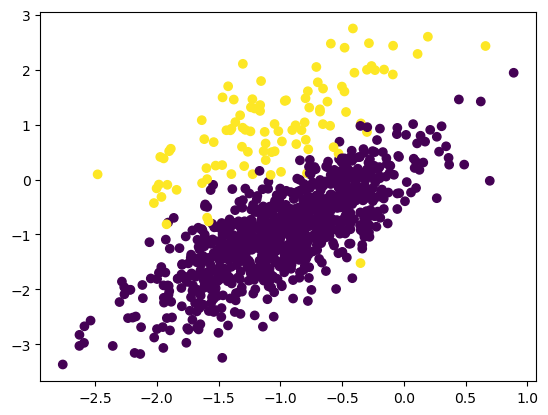

In [12]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

"""
plt.scatter() → creates a scatter plot (used to plot 2D data points).

final_df['f1'] → these are the x-axis values (feature 1).

final_df['f2'] → these are the y-axis values (feature 2).

c=final_df['target'] →

This decides the "color" of each point based on its class label (target).

Example:

Points with target = 0 → one color (say blue)

Points with target = 1 → another color (say orange)

So visually —
✅ You see how your two features (f1, f2) are distributed
✅ And how the two classes (0 & 1) are separated (or mixed)
"""

In [17]:
# To use SMOTE we will use imblearn Library
from imblearn.oversampling import SMOTE

ModuleNotFoundError: No module named 'imblearn.oversampling'

In [18]:
import sys
print(sys.executable)

C:\Users\KALPESH\anaconda3\python.exe


In [1]:
!C:\Users\KALPESH\anaconda3\python.exe -m pip install imbalanced-learn



## 5 Number summary and box plot

#### Minimum, Maximum, Median, Q1, Q2, IQR

In [2]:
import numpy as np

In [3]:
lst_marks=[45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74]
minimum,Q1,median,Q3,maximum=np.quantile(lst_marks,[0,0.25,0.50,0.75,1.0])

In [4]:
minimum,Q1,median,Q3,maximum

(np.float64(32.0),
 np.float64(54.0),
 np.float64(67.0),
 np.float64(89.0),
 np.float64(99.0))

In [5]:
IQR= Q3-Q1
print(IQR)

35.0


In [8]:
lower_fence = Q1-1.5*(IQR) #formula for the lower fence
higher_fence = Q3+1.5*(IQR) #formula for the higher fence

In [11]:
lower_fence


np.float64(1.5)

In [10]:
higher_fence

np.float64(141.5)

#### Box plot

In [13]:
lst_marks=[45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74]

In [18]:
import seaborn as sns
#for boxplot we use seaborn library

<Axes: >

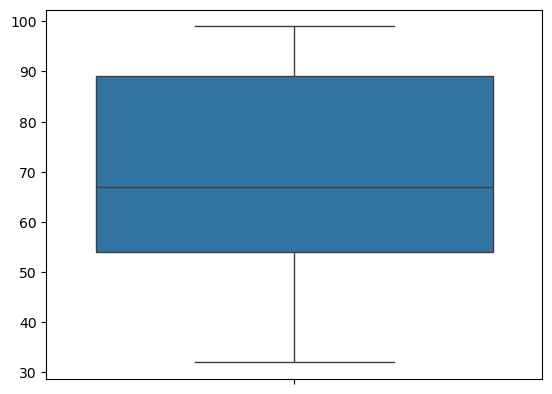

In [19]:
sns.boxplot(lst_marks)

In [23]:
lst_marks=[-100,-200,45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74,150,170 ,180]

<Axes: >

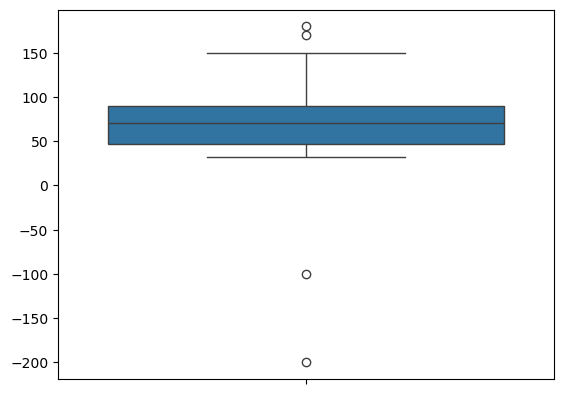

In [24]:
sns.boxplot(lst_marks)

In [26]:
# So above small circles are the outliers which we have seen 

#### Data Encoding nominal or OHE

In [28]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [31]:
## create a simple data frame
df = pd.DataFrame({'color':['red','blue','green','green','red',
                           'blue']})

In [32]:
df

,color
0,red
1,blue
2,green
3,green
4,red
5,blue


In [33]:
## Create an instance of OneHotEncoder
encoder = OneHotEncoder()

"""
Why we need it:
Machine learning models can’t directly understand text data (like “Red”, “Blue”, “Green”).
So we use OneHotEncoder to convert them into numeric format — each category becomes a separate column with 0 or 1.
"""

In [41]:
## Perform fit and transform
encoded = encoder.fit_transform(df[['color']]).toarray()

In [ ]:
"""
Step 1: df[['color']]

This selects the column named “color” from your DataFrame —
but in double brackets [['color']] so it becomes a 2D table (not just a single list).
✅ Because sklearn’s encoder needs data in 2D form.

Step 2: encoder.fit_transform(...)

Now your encoder (which we created earlier using OneHotEncoder()) will:
fit() → find all unique categories (Red, Blue, Green)
transform() → convert them into 0s and 1s (One-Hot Encoding)

Step 3: .toarray()

The output from sklearn is a sparse matrix (memory-efficient format).
.toarray() converts it into a normal NumPy array — so you can easily print or see it.

✅ In short:
This line takes your text categories from the “color” column
and converts them into numeric form so that machine learning models can understand them.
"""

In [42]:
import pandas as pd
encoder_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

In [ ]:
"""
1) encoded
→ This is the NumPy array we got from:
It contains 0s and 1s — but no column names yet.

2) encoder.get_feature_names_out()
→ This gives readable column names automatically, based on your feature and its unique categories.

3) pd.DataFrame(encoded, columns=...)
→ This creates a new DataFrame with proper column names.

"""  

    

In [44]:
encoder_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [47]:
###for new data
encoder.transform([['blue']]).toarray()

C:\Users\KALPESH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [48]:
pd.concat([df,encoder_df],axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


In [49]:
import seaborn as sns
sns.load_dataset('tips')

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### Label Encoding

In [50]:
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [51]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder = LabelEncoder()

In [ ]:
"""
What LabelEncoder does:

It converts each category into a unique integer.
In OHE it gives output in 1 and 0 format and 
in LabelEncoder it gives in 1, 2, 3... as per alphabetical order of the letters format
blue =0, green=1, red=2 -> blue comes first so 0 is given to blue and 2 is given to red.
"""

In [54]:
lbl_encoder.fit_transform(df['color'])

## LabelEncoder expects a 1D list, not a 2D list i.e [] not [[]]

## Here alphabetically nos are given to the data points
## blue =0, green=1, red=2 -> blue comes first so 0 is given to blue and 2 is given to red.

C:\Users\KALPESH\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 0, 1, 1, 2, 0])

In [56]:
lbl_encoder.transform(['red'])

C:\Users\KALPESH\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2])

In [57]:
'''
Disadvantages of Label Encoding
1. Creates False Order (Ranking Problem)

Label encoding assigns numbers like 0, 1, 2…

But machine learning models think numbers have order or distance.

Example: The model may think Red (2) > Green (1) > Blue (0) — which makes no sense!

💡 So it introduces a fake relationship between categories that don’t have any natural order.

2. Can Mislead Algorithms

Algorithms like Linear Regression, Logistic Regression, SVM, Neural Networks use numeric values in calculations.

Because of the numeric encoding, they may treat one category as “greater” or “lesser” than another — which can hurt accuracy.
'''

'\nDisadvantages of Label Encoding\n1. Creates False Order (Ranking Problem)\n\nLabel encoding assigns numbers like 0, 1, 2…\n\nBut machine learning models think numbers have order or distance.\n\nExample: The model may think Red (2) > Green (1) > Blue (0) — which makes no sense!\n\n💡 So it introduces a fake relationship between categories that don’t have any natural order.\n\n2. Can Mislead Algorithms\n\nAlgorithms like Linear Regression, Logistic Regression, SVM, Neural Networks use numeric values in calculations.\n\nBecause of the numeric encoding, they may treat one category as “greater” or “lesser” than another — which can hurt accuracy.\n'

In [58]:
## So to solve this problem we have ordinal encoding

### Ordinal Encoding

In [ ]:
"""
What is Ordinal Encoding?

Ordinal encoding is used when categorical values have a natural order or ranking.
It converts them into numbers based on their order.

Example:

Size → ['Small', 'Medium', 'Large']
Ordinal Encoded → [0, 1, 2]

if you change the order: [['Large'], ['Medium'], ['Small']]
Then it will learn:
Large → 0, Medium → 1, Small → 2

Diff betw Label And Ordinal Encoding:
1️⃣ Label Encoding
➡ Used when the categories don’t have any order (they’re just names).
👉 LabelEncoder just gives numbers (alphabetically or by order of appearance):
Eg: Red → 2
    Blue → 0
    Green → 1

Here, 2 > 0 doesn’t mean “Red is greater than Blue.”

It’s just an ID number — no ranking or hierarchy.

✅ Used for:

Nominal data (no order)
e.g. Color, City, Name, Gender

2️⃣ Ordinal Encoding

➡ Used when the categories have a natural order.
sizes = ['Small', 'Medium', 'Large']
Small → 0
Medium → 1
Large → 2

Now the numbers have meaning:
0 < 1 < 2 → “Small < Medium < Large”.

✅ Used for:

Ordered data (ranking matters)
e.g. Education level, Size, Satisfaction level (Low–Medium–High)
"""

In [60]:
from sklearn.preprocessing import OrdinalEncoder

In [65]:
## Create a sample dataframe with an ordinal variable
df = pd.DataFrame({'size': ['small','medium','large','medium','small','large']})

In [66]:
df

,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [68]:
## Create an instance of ordinal encoder and then fit_transform
encoder=OrdinalEncoder(categories=[['small','medium','large']])

In [69]:
encoder.fit_transform(df[['size']])

array([[0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.]])

In [70]:
encoder.transform([['small']])

C:\Users\KALPESH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[0.]])

### Target guided Ordinal Encoding

In [1]:
import pandas as pd
df = pd.DataFrame({
    'city' : ['New York','London','Paris','Tokyo','New York','Paris'],
    'Price' : [200,150,300,250,180,320] })

In [2]:
df

,city,Price
0,New York,200
1,London,150
2,Paris,300
3,Tokyo,250
4,New York,180
5,Paris,320


In [3]:
## If we have replace the New York with numerical value we take the avg of that 2 nos
# (200+180)/2 -> 190

mean_price=df.groupby('city')['Price'].mean().to_dict()

In [4]:
df['city_encoded']=df['city'].map(mean_price)

In [5]:
df

,city,Price,city_encoded
0,New York,200,190.0
1,London,150,150.0
2,Paris,300,310.0
3,Tokyo,250,250.0
4,New York,180,190.0
5,Paris,320,310.0
